(14500,)
(14500,)
(14500,)
(14500,)
(14500,)
(14500,)


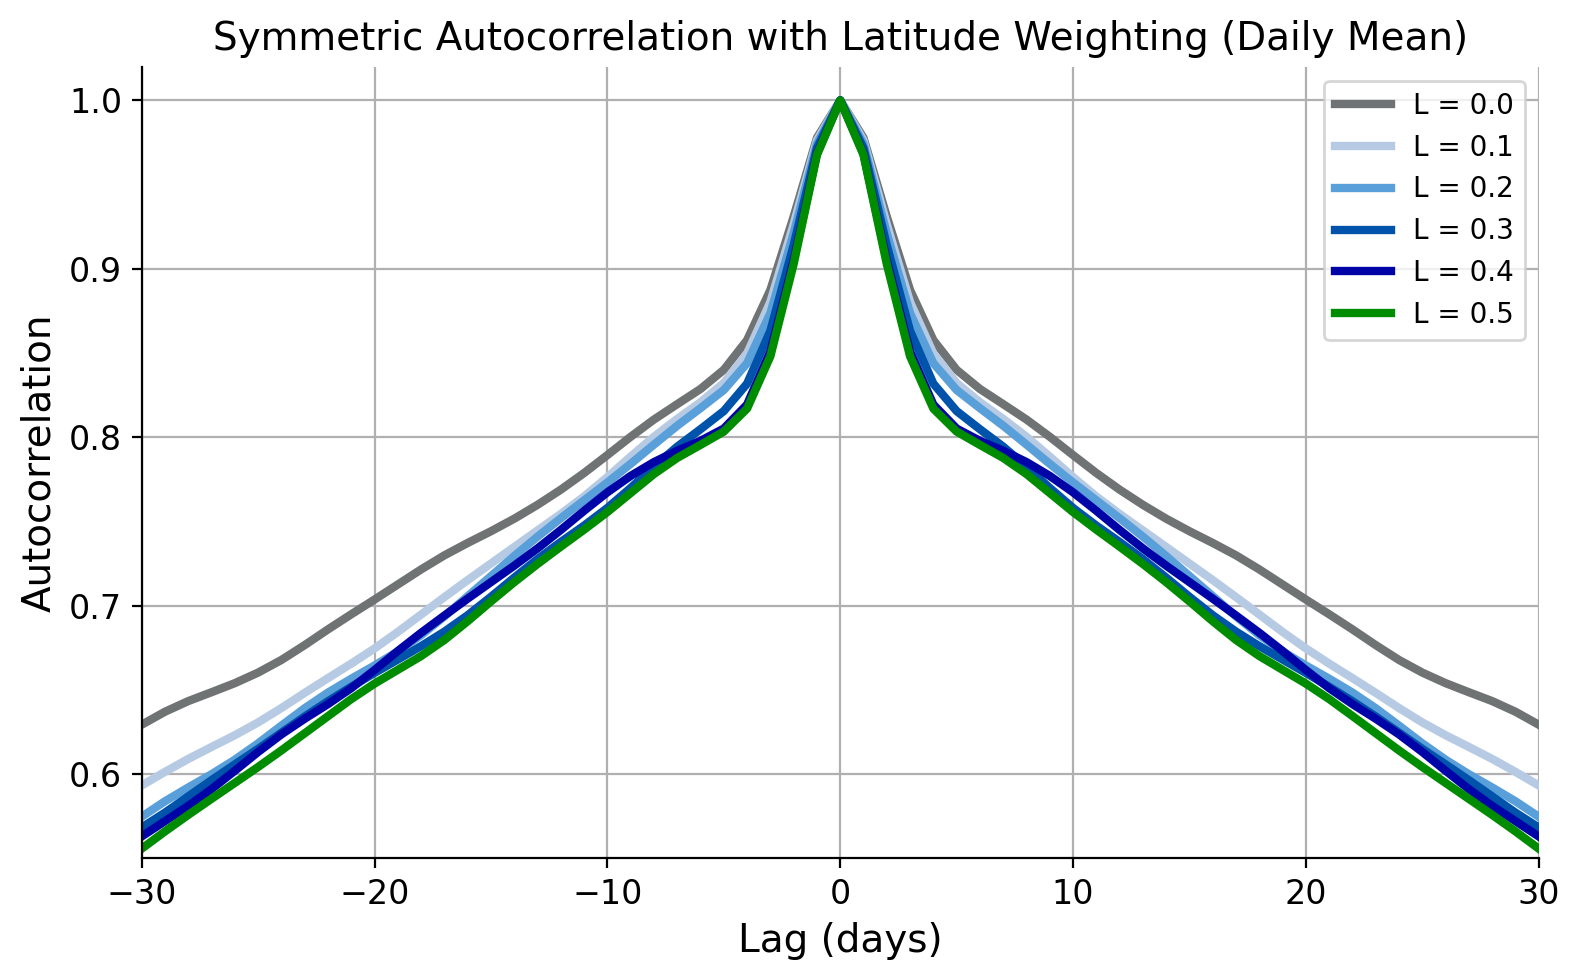

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys

sys.path.append("back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/")
from EOF import EOF


class Moist_Dycore_Package:
    def __init__(self, zonal_dimension: int = 3):
        self.zonal_dimension = zonal_dimension

    def zonal_mean(self, data):
        return np.mean(data, axis=self.zonal_dimension, keepdims=True)

    def zonal_anomaly(self, data):
        mean = self.zonal_mean(data)
        np.subtract(data, mean, out=data)
        return data

    def load_data(self, file_path, variable_name):
        with h5py.File(file_path, "r") as file:
            return np.array(file[variable_name], dtype=np.float32)

    def calculate_daily_mean(self, data):
        """
        Calculate daily mean data from 6-hourly data.
        Assumes the time dimension is the first axis.
        """
        num_days = data.shape[0] // 4  # Calculate number of days
        daily_mean = data[:num_days * 4].reshape(num_days, 4, -1).mean(axis=1)
        return daily_mean

    def calculate_EOF_with_custom_class(self, input_data, latitudes, n_components: int = 32, field: str = "2D"):
        weights = np.sqrt(np.cos(np.radians(latitudes)))
        weighted_data = input_data * weights

        eof_instance = EOF((weighted_data,), n_components=n_components, field=field)
        eof_instance.get()

        EOF_modes = eof_instance.EOF[:2]
        PCs = eof_instance.PC[0]
        explained_variance = eof_instance.explained

        PCs_normalized = PCs / PCs.std(axis=0)

        return EOF_modes, PCs_normalized, explained_variance

    def symmetric_autocorr(self, x, max_lag, split_to_chunk, window_length, overlap=250):
        if not split_to_chunk:
            corr = np.zeros(2 * max_lag + 1)
            for l in range(-max_lag, max_lag + 1):
                if l == 0:
                    corr[l + max_lag] = 1.0
                elif l > 0:
                    corr[l + max_lag] = np.corrcoef(x[l:], x[:-l])[0][1]
                else:
                    corr[l + max_lag] = np.corrcoef(x[:l], x[-l:])[0][1]
            return corr
        else:
            step_size = window_length - overlap
            num_windows = (len(x) - overlap) // step_size
            corr = np.zeros((num_windows, 2 * max_lag + 1))

            for i in range(num_windows):
                start = i * step_size
                end = start + window_length
                x_window = x[start:end]

                if len(x_window) < window_length:
                    break

                for l in range(-max_lag, max_lag + 1):
                    if l == 0:
                        corr[i, l + max_lag] = 1.0
                    elif l > 0:
                        corr[i, l + max_lag] = np.corrcoef(x_window[l:], x_window[:-l])[0, 1]
                    else:
                        corr[i, l + max_lag] = np.corrcoef(x_window[:l], x_window[-l:])[0, 1]

            return corr.mean(axis=0)


# Initialize the Package
moist_dycore = Moist_Dycore_Package(zonal_dimension=3)

# Parameters
PR_values = [0, 10, 20, 30, 40, 50]
colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218],
                   [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0
auto_length = 100
window_length = 500
split_to_chunk = False
latitudes = np.linspace(0, 90, 32)

# Load data, calculate daily mean, and compute PC1 for all PR values
PC1_all  = []
EOFs_all = []


for PR in PR_values:
    file_path = f"/data92/PeterChang/1120_preprocessing/PR{PR}/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
    variable_name = "u"
    u_data = moist_dycore.load_data(file_path, variable_name)
    
    # Calculate daily mean
    u_daily = moist_dycore.calculate_daily_mean(u_data)
    # Use the custom EOF class
    EOFs, PC_normalized, _ = moist_dycore.calculate_EOF_with_custom_class(u_daily[5000:, 32:], latitudes, n_components=32, field="1D")
    EOFs_all.append(EOFs[:])  # Extract normalized PC1 for the current PR value
    PC1_all.append(PC_normalized[:])  # Extract normalized PC1 for the current PR value
    print(PC_normalized[:].shape)
    
    

PC1_all  = np.array(PC1_all)
EOFs_all = np.array(EOFs_all)


# Calculate symmetric autocorrelation for PC1
autocorr_results = []
for i in range(len(PR_values)):
    autocorr_results.append(
        moist_dycore.symmetric_autocorr(PC1_all[i, :], auto_length, split_to_chunk, window_length)
    )

# tau for plotting
tau_full = np.arange(-auto_length, auto_length + 1)

# Plot the symmetric autocorrelation
fig, ax = plt.subplots(1, figsize=(8, 5), dpi=200)
mpl.rcParams['axes.linewidth'] = 1.5

for i, PR in enumerate(PR_values):
    ax.plot(tau_full, autocorr_results[i], label=f"L = {PR * 0.01}", color=colors[i], lw=3)

# Customize plot
ax.set_title("Symmetric Autocorrelation with Latitude Weighting (Daily Mean)", fontsize=14)
ax.set_xlabel("Lag (days)", fontsize=14)
ax.set_ylabel("Autocorrelation", fontsize=14)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.xlim([-30, 30])
plt.ylim([0.55, 1.02])
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [2]:
start_day = 500+5000
end_day   = 20000

day_length = len(np.arange(start_day, end_day))
print(day_length)
print(f"start_day = {start_day}, end_day = {end_day}, total day = {day_length}")

Uzm_all = np.zeros((6, day_length, 64))
# num_days = Uzm_6hourly_all.shape[0] // 4  # Ensure divisible by 4
a = 0
for PR in [0,10,20,30,40,50]:
    with h5py.File(f"/data92/PeterChang/1120_preprocessing//PR{PR}/climatology/u_add_time_dim/u_climatology_add_time_dim.h5") as f:
        day = f["u"][int((start_day-500)*4):,:].shape[0]
        Uzm_all[a] = f["u"][int(start_day-500)*4:,:].reshape(int(day/4),4,64).mean(axis=1)
        
    a += 1

14500
start_day = 5500, end_day = 20000, total day = 14500


In [3]:
EMF = np.zeros((6, day_length, 64))
aa = 0
for PR in range(0, 60, 10):
        EMF_file = f"/data92/PeterChang/1120_preprocessing/PR{PR}/climatology/EMF_add_time_dim/EMF_climatology_add_time_dim.h5"
        with h5py.File(EMF_file,'r') as f :
            EMF[aa] = f["EMF"][int(start_day-500)*4:,:].reshape(int(day/4),4,64).mean(axis=1)
        aa += 1

In [4]:
radius  = 6.37122e6
y = np.linspace(-90,90,64)
yd = np.deg2rad(y)
cy = np.cos(yd)
cy2 = cy **2

sigma_onlyz = np.linspace(0,1,20)
yy, sigma_mean2 = np.meshgrid(y, sigma_onlyz)

dmdy = np.zeros((6, day_length, 64))
for a in range(6):
    Mzm = EMF[a] # EMF_oringin_grid[a]
    print(Mzm.shape)
    
    for i in range(1,64-1):
        dmdy[a,:,i] = -(Mzm[:,i+1] * (cy[i]**2) - Mzm[:,i-1]* (cy[i]**2)) / (radius * (cy[i]**2) * (yd[i+1] - yd[i-1]))
    # dmdy[a,:,:,1:-1] = -((Mzm[:,:,2:] - Mzm[:,:,:-2]) * cy2[1:-1]) / (radius * (cy2[1:-1]) * (yd[2:] - yd[:-2]))
    
    dmdy[a,:, 0] = -((Mzm[:, 1] - Mzm[:, 0]) * cy2[0])  / (radius* cy2[0]  *(yd[ 1] - yd[ 0]))
    dmdy[a,:,-1] = -((Mzm[:,-1] - Mzm[:,-2]) * cy2[-1]) / (radius* cy2[-1] *(yd[-1] - yd[-2]))
print(dmdy.shape)



(14500, 64)
(14500, 64)
(14500, 64)
(14500, 64)
(14500, 64)
(14500, 64)
(6, 14500, 64)


In [5]:
prec_daily_all = np.zeros((6,day_length,16))
aa = 0
for PR in range(0,60,10):
    with h5py.File(f"/data92/PeterChang/1120_preprocessing/PR{PR}/variability/prec/prec_PR{PR}.h5"
    ) as f:
        prec = f["prec"][int(start_day-500)*4:, 32-8:32+8] #(time, y)
                
    num_days = prec.shape[0] // 4  # Ensure divisible by 4
    prec_daily_all[aa] = prec[:num_days * 4].reshape(num_days, 4, *prec.shape[1:]).mean(axis=1)
    aa += 1

Text(0.5, 0, 'Latitude')

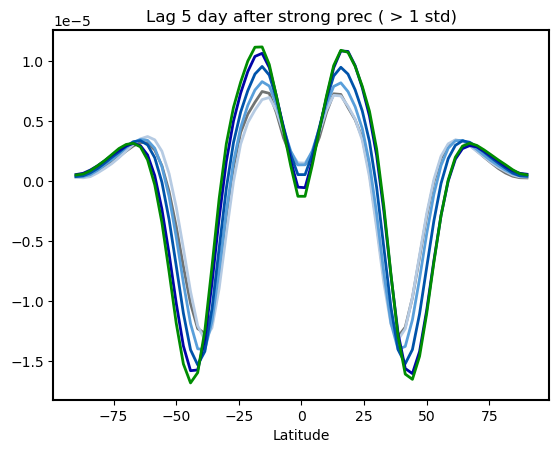

In [6]:
prec_daily_all_mean = prec_daily_all.mean(axis=2)
plt.figure()
aa  = 0
for i in range(6):
    time_idx = np.where(prec_daily_all_mean[aa] > prec_daily_all_mean[aa].mean() + prec_daily_all_mean[aa].std())
    time_idx_lag = np.asarray(time_idx) + 5
    time_idx_lag = time_idx_lag[time_idx_lag < dmdy.shape[1] - 5]
    plt.plot(y, dmdy[aa, time_idx_lag].mean() - dmdy[aa].mean(axis=0), color=colors[i], lw=2)
    
    aa += 1

plt.title("Lag 5 day after strong prec ( > 1 std)")
plt.xlabel("Latitude")

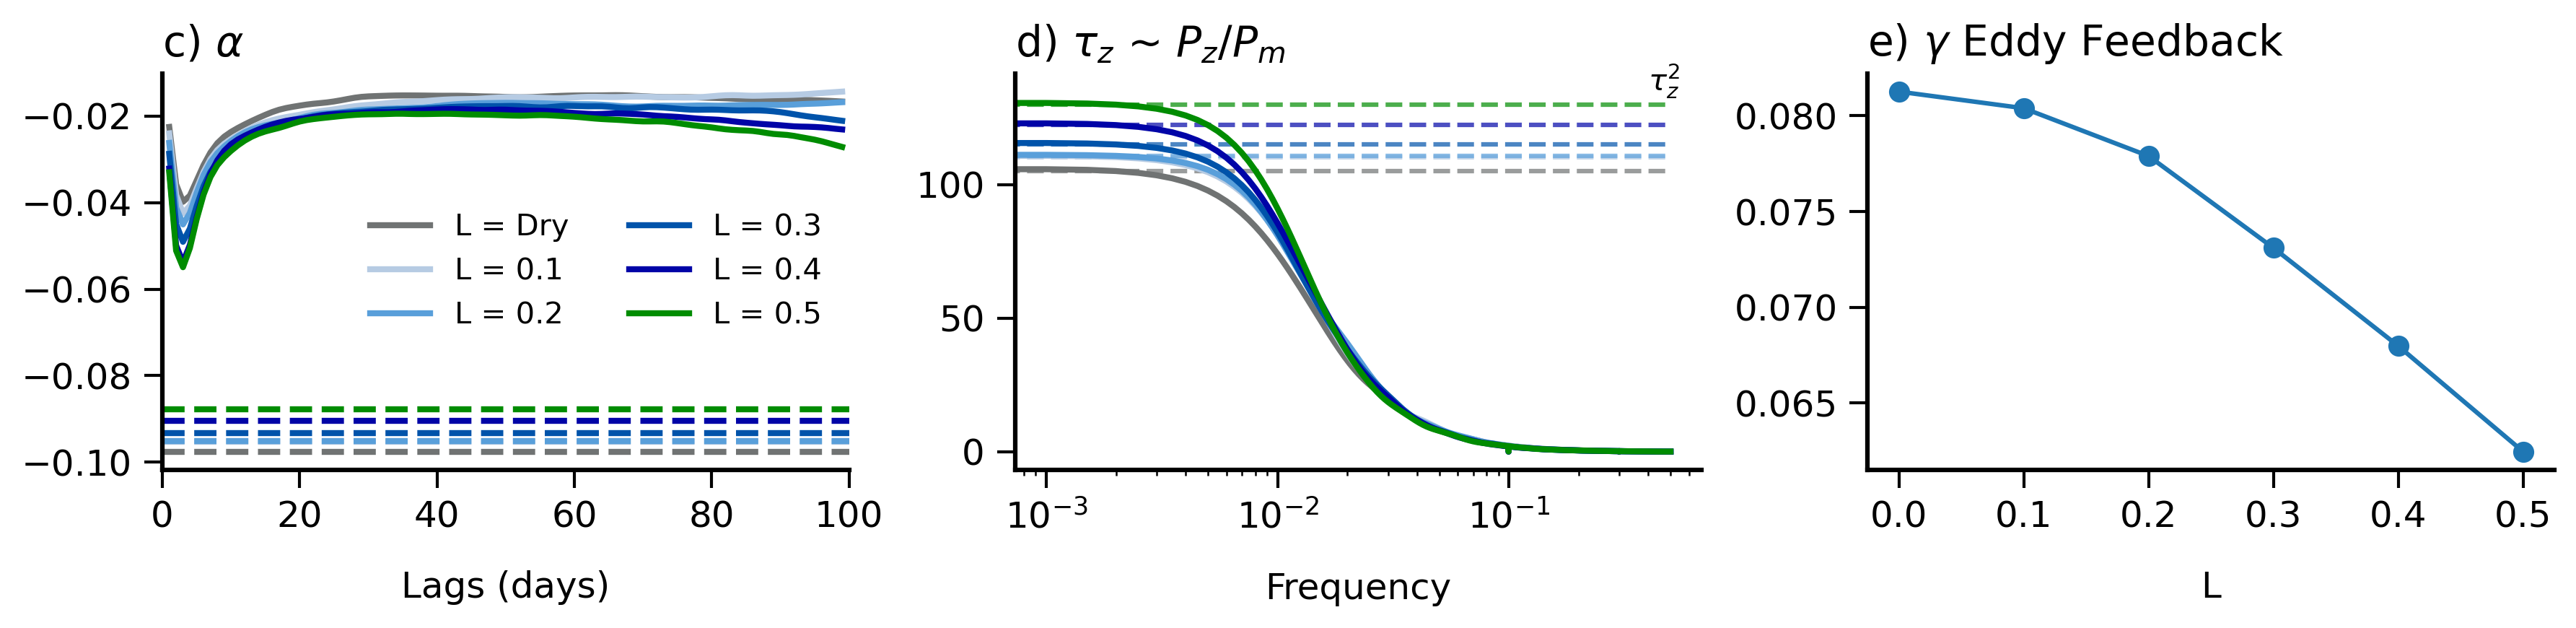

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft
from scipy.ndimage import gaussian_filter1d

# Parameters
num_exp = 6
num_lat = 32
lg = 2000  # Length of the interval
overlap = 1000  # Overlap between windows
colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218], 
                   [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0

# Placeholder for results
tau_z_square = np.zeros(num_exp)
m_fig3 = np.zeros((num_exp, day_length))
PP_all_u = np.zeros((num_exp, day_length))
total_L = np.zeros((num_exp, 100))
total_L_final = np.zeros(num_exp)
fig4_final = np.zeros(num_exp)
take_min_day = 90  #40
take_max_day = 100 #60
take_len_day = take_max_day - take_min_day

# Helper functions
def compute_running_mean(data, window_size):
    """Compute running mean for smoothing."""
    cumsum = np.cumsum(np.insert(data, 0, 0))
    return (cumsum[window_size:] - cumsum[:-window_size]) / float(window_size)

def compute_fft_cross_spectrum(signal1, signal2, lg, overlap):
    """Compute FFT-based cross-spectrum for two signals."""
    Pz_all = np.zeros(lg, dtype=np.complex_)
    Pm_all = np.zeros(lg, dtype=np.complex_)
    n_segments = 0

    for i in range(0, len(signal1) - lg + 1, lg - overlap):
        hanning_window = np.hanning(lg)
        Z_segment = fft(signal1[i:i + lg] * hanning_window) / len(hanning_window)
        M_segment = fft(signal2[i:i + lg] * hanning_window) / len(hanning_window)

        Pz_all += Z_segment * np.conjugate(Z_segment)
        Pm_all += M_segment * np.conjugate(M_segment)
        n_segments += 1

    return Pz_all / n_segments, Pm_all / n_segments

# Generate `m_fig3` and `PP_all_u`
for exp_idx in range(num_exp):
    u_weighted = Uzm_all[exp_idx, :, num_lat:] * (cy[num_lat:] ** 0.5)
    single_EOF_u = EOF((u_weighted,), n_components=num_lat, field="1D")
    single_EOF_u.get()

    PP_all_u[exp_idx] = single_EOF_u.PC[0]
    EOF_u_final = single_EOF_u.EOF[0]
    m_fig3[exp_idx] = np.dot(dmdy[exp_idx, :, num_lat:] * (cy[num_lat:] ** 0.5), EOF_u_final)

# Plot initialization
# fig, ax = plt.subplots(1, 3, figsize=(15, 4), dpi=300)
fig, ax = plt.subplots(1,3, figsize=(12,3), dpi=300.)

import matplotlib as mpl

mpl.rcParams['axes.linewidth'] = 1.5

# Compute cross-spectrum and plot for each experiment
for exp_idx in range(num_exp):
    Pz_all, Pm_all = compute_fft_cross_spectrum(PP_all_u[exp_idx], m_fig3[exp_idx], lg, overlap)
    freq = np.fft.fftfreq(lg)
    spectrum = Pz_all / Pm_all / (86400**2)

    # Smooth spectrum for better visualization
    tau_smoothed = compute_running_mean(spectrum.real, 5)
    freq_smoothed = compute_running_mean(freq, 5)
    spectrum_gaussian = gaussian_filter1d(tau_smoothed, sigma=8)
    sorted_idx = np.argsort(freq_smoothed)

    # Plot smoothed spectrum
    ax[1].plot(freq_smoothed[sorted_idx], spectrum_gaussian[sorted_idx], 
               label=f"L={exp_idx * 0.1:.1f}", color=colors[exp_idx], lw=2)

    # Compute and plot tau_z_square
    tau_z_square[exp_idx] = spectrum_gaussian[sorted_idx][lg//2:lg//2+10].max()
    ax[1].hlines(tau_z_square[exp_idx], xmin=freq_smoothed[sorted_idx].min(), 
                 xmax=freq_smoothed[sorted_idx].max(), linestyle="--", color=colors[exp_idx], alpha=0.7)

# Compute logarithmic derivative for Fig. 3(a)
for exp_idx in range(num_exp):
    autocorr_data = autocorr_results[exp_idx]  # Use the provided autocorrelation results in Fig.1
    for i in range(1, 100):
        total_L[exp_idx, i] = np.log(autocorr_data[100 + i]) / i

    total_L_final[exp_idx] = np.mean(total_L[exp_idx, take_min_day:take_max_day])

    if exp_idx == 0:
        ax[0].plot(range(1, 100), total_L[exp_idx, 1:], label=f"L = Dry", color=colors[exp_idx], lw=2)
    else:
        ax[0].plot(range(1, 100), total_L[exp_idx, 1:], label=f"L = {exp_idx * 0.1:.1f}", color=colors[exp_idx], lw=2)
    
    ax[0].axhline(-1 / (tau_z_square[exp_idx] ** 0.5), linestyle="--", color=colors[exp_idx], lw=2)

# Calculate feedback differences for Fig. 3(c)
for exp_idx in range(num_exp):
    fig4_final[exp_idx] = np.median(total_L[exp_idx, take_min_day:take_max_day]) - (-1 / tau_z_square[exp_idx]**0.5)

# Plot feedback differences
L_values = np.arange(0, 0.6, 0.1)
ax[2].scatter(L_values, fig4_final)
ax[2].plot(L_values, fig4_final)

# Final plot customizations
ax[0].set_title(r"c) $\alpha$", loc="left", fontsize=14)
# ax[0].set_title(r"a) $\alpha$ and $-1/\tau_z$", loc="left", fontsize=14)
ax[0].set_xlabel("Lags (days)", fontsize=12 , labelpad=12)
ax[0].set_xlim([0, 100])
ax[0].legend(loc = 0, prop={'size': 10},frameon=False, ncols=2)

ax[1].set_title(r"d) $\tau_z$ ~ $P_z / P_m$", loc="left", fontsize=14)
ax[1].set_xlabel("Frequency", fontsize=12 , labelpad=12)
ax[1].text(0.4, 135, r"$\tau ^2 _{z}$")
ax[1].set_xscale("log")

ax[2].set_title(r"e) $\gamma$ Eddy Feedback", loc="left", fontsize=14)
ax[2].set_xlabel("L", fontsize=12 , labelpad=12)

for i in range(3):
    ax[i].spines["right"].set_visible(False)
    ax[i].spines["top"].set_visible(False)
    ax[i].tick_params(axis='x', labelsize=12, pad=4)
    ax[i].tick_params(axis='y', labelsize=12, pad=4)
    ax[i].tick_params(direction='out', length=6, width=1)

plt.tight_layout()
plt.show()

In [8]:
sigma_fixed = 1  # standard deviation
PC1_all_hat = np.zeros(PC1_all.shape)
for i in range(PC1_all.shape[0]):
    residuals = np.array(np.random.normal(loc=0, scale=sigma_fixed, size=len(list(PC1_all[0]))))
    for j in range(0,PC1_all.shape[1]-1):
        PC1_all_hat[i,j+1] = total_L[i, 1] * PC1_all[i,j] + residuals[i]

In [9]:
# 03/08(Sat.) getting off work haven't finish
PC1_all_hat_lag1 = np.zeros((PC1_all.shape[0], PC1_all.shape[1]))
print(PC1_all_hat_lag1.shape)
for i in range(6):
    PC1_all_hat_lag1[i,1:] = PC1_all_hat[i,:-1]
print(PC1_all_hat[0,:5])
print(PC1_all_hat_lag1[0,:5])


(6, 14500)
[ 0.         -1.02119232 -1.02207909 -1.02466556 -1.02561547]
[ 0.          0.         -1.02119232 -1.02207909 -1.02466556]


In [10]:
# Calculate symmetric autocorrelation for PC1
autocorr_results_for_stat = []
for i in range(len(PR_values)):
    autocorr_results_for_stat.append(
        moist_dycore.symmetric_autocorr(PC1_all_hat[i,:], auto_length, split_to_chunk, window_length)
    )

In [ ]:
import numpy as np
import multiprocessing as mp

# 限制 NumPy / OpenMP / BLAS 只使用 1 核心，避免意外占用 64 核
import os


# Number of simulations
AR_num = 2  # total_L: AR{number}
final_5_log = np.zeros((6, 100))
final_95_log = np.zeros((6, 100))

num_simulations = 500
sigma_fixed = 0.5  # standard deviation
num_cpus = 4  # 限制 CPU 使用数量

# 共享 memory
manager = mp.Manager()
total_L_shared = manager.list(total_L.tolist())  # 把 total_L 共享给子进程
PC1_all_shared = manager.list(PC1_all.tolist())  # 把 PC1_all 共享给子进程

def compute_autocorr(args):
    """计算单次模拟的自相关"""
    sim, AR = args
    PC1_all_hat = np.zeros((len(PC1_all_shared), len(PC1_all_shared[0])))  # 避免子进程修改主进程数据
    total_L = np.array(total_L_shared)
    PC1_all = np.array(PC1_all_shared)

    for i in range(len(PC1_all)):
        residuals = np.random.normal(loc=0, scale=sigma_fixed, size=len(PC1_all[0]))
        for j in range(len(PC1_all[0]) - 1):
            PC1_all_hat[i, j + 1] = total_L[i, AR] * PC1_all[i, j] + residuals[i]

    # 计算对称自相关
    autocorr_results = []
    for i in range(len(PR_values)):
        autocorr_results.append(
            moist_dycore.symmetric_autocorr(PC1_all_hat[i, :], auto_length, split_to_chunk, window_length)
        )
    return np.array(autocorr_results)

for AR in range(1, AR_num):
    print(f"Calculating AR{AR}...")

    # 创建进程池并行计算
    with mp.Pool(processes=num_cpus) as pool:
        all_autocorr_results = pool.map(compute_autocorr, [(sim, AR) for sim in range(num_simulations)], chunksize=10)

    # 转换为 NumPy 数组
    all_autocorr_results = np.array(all_autocorr_results)

    # 计算 5% 和 95% 置信区间
    conf_interval_5 = np.percentile(all_autocorr_results, 5, axis=0)
    conf_interval_95 = np.percentile(all_autocorr_results, 95, axis=0)

    # 确保索引不越界
    valid_range = min(100, conf_interval_5.shape[1])
    conf_interval_5_log = np.log(conf_interval_5[:, :valid_range]) / np.arange(1, valid_range + 1)
    conf_interval_95_log = np.log(conf_interval_95[:, :valid_range]) / np.arange(1, valid_range + 1)

    # 存储结果
    final_5_log[:, AR-1] = conf_interval_5_log[:, -1]  # 取最后一列
    final_95_log[:, AR-1] = conf_interval_95_log[:, -1]  # 取最后一列

# 保存结果
np.save("final_5_log.npy", final_5_log)
np.save("final_95_log.npy", final_95_log)

print("Files saved: final_5_log.npy, final_95_log.npy")


Calculating AR1...
